# UNSW-NB15 official-split evaluation

Trains on UNSW_NB15_training-set.csv and tests on UNSW_NB15_testing-set.csv as given, with no
pooling or re-splitting. The official train and test files have different attack ratios, so
pooling and re-splitting would leak near-duplicate rows across the split.

All models are thresholded using Youden's J (argmax(TPR minus FPR)) rather than F1, since F1
thresholds tuned on one file's positive rate transfer poorly to the other's.

Covers Random Forest, Gradient-Boosted Trees, Isolation Forest, and GDN/TGCN. Section 6 covers
the graph construction changes from the previous version.


## 0. Setup

In [1]:

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    confusion_matrix, f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:

!pip install xgboost -q
from xgboost import XGBClassifier
print("Done")


Done


## 1. Load data

In [3]:

TRAIN_FILE = "UNSW_NB15_training-set.csv"
TEST_FILE  = "UNSW_NB15_testing-set.csv"

for f in (TRAIN_FILE, TEST_FILE):
    if not os.path.exists(f):
        raise FileNotFoundError(f"Could not find '{f}' in {os.getcwd()}.")

df_train_raw = pd.read_csv(TRAIN_FILE)
df_test_raw  = pd.read_csv(TEST_FILE)
print("Official training-set file:", df_train_raw.shape)
print("Official testing-set file: ", df_test_raw.shape)
print(f"Train attack rate: {df_train_raw['label'].mean():.3f}  |  Test attack rate: {df_test_raw['label'].mean():.3f}")


Official training-set file: (175341, 45)
Official testing-set file:  (82332, 45)
Train attack rate: 0.681  |  Test attack rate: 0.551


## 2. Why the official split, not pooling - one diagnostic

Kept minimal: a single duplicate-count check justifying the protocol choice, not a full ablation
suite.


Duplicate rows within official training file: 67,601 (38.6%)
Rows identical across train & test files: 940


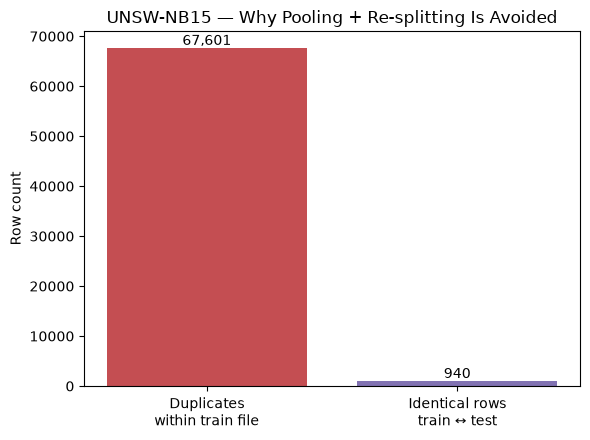

In [4]:

compare_cols = [c for c in df_train_raw.columns if c != "id"]
dup_in_train = df_train_raw.duplicated(subset=compare_cols).sum()
overlap = pd.merge(
    df_train_raw[compare_cols].drop_duplicates(),
    df_test_raw[compare_cols].drop_duplicates(),
    how="inner"
).shape[0]
print(f"Duplicate rows within official training file: {dup_in_train:,} ({dup_in_train/len(df_train_raw):.1%})")
print(f"Rows identical across train & test files: {overlap:,}")

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Duplicates\nwithin train file", "Identical rows\ntrain \u2194 test"],
              [dup_in_train, overlap], color=["#C44E52", "#8172B2"])
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(b.get_height()):,}", ha="center", va="bottom")
ax.set_ylabel("Row count")
ax.set_title("UNSW-NB15 — Why Pooling + Re-splitting Is Avoided")
plt.tight_layout()
plt.savefig("fig_leakage_duplicate_counts.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Shared preprocessing (tabular models)

In [5]:

def collapse_rare_categories(train_series, test_series, min_freq=0.005):
    freq = train_series.value_counts(normalize=True)
    keep = set(freq[freq >= min_freq].index)
    train_out = train_series.where(train_series.isin(keep), other="other")
    test_out  = test_series.where(test_series.isin(keep), other="other")
    return train_out, test_out


def preprocess_split(df_train, df_test):
    train, test = df_train.copy(), df_test.copy()
    for c in ("id", "attack_cat"):
        if c in train.columns: train = train.drop(columns=[c])
        if c in test.columns:  test = test.drop(columns=[c])

    y_train = train.pop("label").astype(int)
    y_test  = test.pop("label").astype(int)

    numeric_cols     = train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in train.columns if c not in numeric_cols]

    train_cat, test_cat = train[categorical_cols].copy(), test[categorical_cols].copy()
    for c in categorical_cols:
        train_cat[c], test_cat[c] = collapse_rare_categories(train_cat[c], test_cat[c])
    train_cat = pd.get_dummies(train_cat, drop_first=True)
    test_cat  = pd.get_dummies(test_cat,  drop_first=True)
    train_cat, test_cat = train_cat.align(test_cat, join="left", axis=1, fill_value=0)

    scaler = StandardScaler()
    train_num = pd.DataFrame(scaler.fit_transform(train[numeric_cols]), columns=numeric_cols, index=train.index)
    test_num  = pd.DataFrame(scaler.transform(test[numeric_cols]),      columns=numeric_cols, index=test.index)

    X_train_final = pd.concat([train_num, train_cat], axis=1)
    X_test_final  = pd.concat([test_num,  test_cat],  axis=1)
    return X_train_final, X_test_final, y_train, y_test


print("preprocess_split() ready.")


preprocess_split() ready.


## 4. Evaluation helpers - one row per model, Youden-J threshold throughout

In [6]:

model_results = {}


def tune_threshold_youden(y_val, probs_val):
    fpr, tpr, thresholds = roc_curve(y_val, probs_val)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx], j_scores[best_idx]


def record_results(name, protocol, train_basis, y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precisions, recalls, _ = precision_recall_curve(y_true, y_prob)
    model_results[name] = {
        "Protocol": protocol, "Train basis": train_basis,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "F2 Score": fbeta_score(y_true, y_pred, beta=2),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob,
        "fpr": fpr, "tpr": tpr, "precisions": precisions, "recalls": recalls,
        "cm": confusion_matrix(y_true, y_pred),
    }
    r = model_results[name]
    print(f"[{name}] Acc={r['Accuracy']:.4f}  F1={r['F1 Score']:.4f}  AUC={r['AUC']:.4f}  PR-AUC={r['PR-AUC']:.4f}")


print("Evaluation helpers ready.")


Evaluation helpers ready.


## 5. Protocol A - pooled random split (context only, not the primary result)

RF and Gradient-Boosted Trees only, for direct comparison against their Section 7 (official
split) counterparts - this pair is the leakage evidence, kept lean.


In [7]:

df_pooled = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
pooled_tr_raw, pooled_te_raw = train_test_split(
    df_pooled, test_size=0.3, random_state=RANDOM_STATE, stratify=df_pooled["label"]
)
X_train_A, X_test_A, y_train_A, y_test_A = preprocess_split(pooled_tr_raw, pooled_te_raw)

X_a_tr, X_a_val, y_a_tr, y_a_val = train_test_split(
    X_train_A, y_train_A, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_A
)
SEARCH_SAMPLE_SIZE = 40000
X_search_a, _, y_search_a, _ = train_test_split(
    X_a_tr, y_a_tr, train_size=min(SEARCH_SAMPLE_SIZE, len(X_a_tr)), random_state=RANDOM_STATE, stratify=y_a_tr
)

rf_param_dist = {"n_estimators": [200, 300, 500], "max_depth": [15, 20, 30],
                  "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", "log2"]}
xgb_param_dist = {"n_estimators": [300, 500, 600], "max_depth": [4, 6, 8],
                   "learning_rate": [0.03, 0.05, 0.1], "subsample": [0.7, 0.85, 1.0],
                   "colsample_bytree": [0.7, 0.85, 1.0]}

rf_search_a = RandomizedSearchCV(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
                                  rf_param_dist, n_iter=10, cv=3, scoring="f1", random_state=RANDOM_STATE, n_jobs=1)
rf_search_a.fit(X_search_a, y_search_a)
rf_a = RandomForestClassifier(**rf_search_a.best_params_, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1)
rf_a.fit(X_a_tr, y_a_tr)
val_probs = rf_a.predict_proba(X_a_val)[:, 1]
thresh, _ = tune_threshold_youden(y_a_val, val_probs)
test_probs = rf_a.predict_proba(X_test_A)[:, 1]
record_results("RF (Protocol A - pooled random)", "A: Pooled random split",
                f"Best params: {rf_search_a.best_params_}", y_test_A, (test_probs > thresh).astype(int), test_probs)

scale_pos_weight_a = (y_a_tr == 0).sum() / (y_a_tr == 1).sum()
xgb_search_a = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", scale_pos_weight=scale_pos_weight_a, random_state=RANDOM_STATE, n_jobs=1, tree_method="hist"),
    xgb_param_dist, n_iter=10, cv=3, scoring="f1", random_state=RANDOM_STATE, n_jobs=1)
xgb_search_a.fit(X_search_a, y_search_a)
xgb_a = XGBClassifier(**xgb_search_a.best_params_, eval_metric="logloss", scale_pos_weight=scale_pos_weight_a,
                       random_state=RANDOM_STATE, n_jobs=1, tree_method="hist")
xgb_a.fit(X_a_tr, y_a_tr)
val_probs = xgb_a.predict_proba(X_a_val)[:, 1]
thresh, _ = tune_threshold_youden(y_a_val, val_probs)
test_probs = xgb_a.predict_proba(X_test_A)[:, 1]
record_results("Gradient-Boosted Trees (Protocol A - pooled random)", "A: Pooled random split",
                f"Best params: {xgb_search_a.best_params_}", y_test_A, (test_probs > thresh).astype(int), test_probs)

del rf_search_a, xgb_search_a, X_search_a, y_search_a
gc.collect()


[RF (Protocol A - pooled random)] Acc=0.9450  F1=0.9557  AUC=0.9917  PR-AUC=0.9954
[Gradient-Boosted Trees (Protocol A - pooled random)] Acc=0.9489  F1=0.9590  AUC=0.9923  PR-AUC=0.9958


181

## 6. Protocol B - official train/test split (**primary result**)

Each model below is logged exactly once, with the Youden-J threshold applied directly (see
Section 4 rationale) - no duplicate rows per model.


In [8]:

X_train_B, X_test_B, y_train_B, y_test_B = preprocess_split(df_train_raw, df_test_raw)
X_b_tr, X_b_val, y_b_tr, y_b_val = train_test_split(
    X_train_B, y_train_B, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train_B
)
X_search_b, _, y_search_b, _ = train_test_split(
    X_b_tr, y_b_tr, train_size=min(SEARCH_SAMPLE_SIZE, len(X_b_tr)), random_state=RANDOM_STATE, stratify=y_b_tr
)
print("Protocol B train:", X_train_B.shape, "| test:", X_test_B.shape)


Protocol B train: (175341, 57) | test: (82332, 57)


### 6a. Random Forest

In [9]:

rf_search_b = RandomizedSearchCV(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
                                  rf_param_dist, n_iter=10, cv=3, scoring="f1", random_state=RANDOM_STATE, n_jobs=1)
rf_search_b.fit(X_search_b, y_search_b)
rf_b = RandomForestClassifier(**rf_search_b.best_params_, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1)
rf_b.fit(X_b_tr, y_b_tr)
val_probs = rf_b.predict_proba(X_b_val)[:, 1]
thresh_rf_b, _ = tune_threshold_youden(y_b_val, val_probs)
test_probs = rf_b.predict_proba(X_test_B)[:, 1]
record_results("Random Forest (Protocol B - official split)", "B: Official train/test split",
                f"Best params: {rf_search_b.best_params_}, threshold={thresh_rf_b:.3f} (Youden J)",
                y_test_B, (test_probs > thresh_rf_b).astype(int), test_probs)


[Random Forest (Protocol B - official split)] Acc=0.8982  F1=0.9134  AUC=0.9838  PR-AUC=0.9878


### 6b. Gradient-Boosted Trees (XGBoost)

Named per the proposal's own §2.2.3 wording ("Random Forest and gradient-boosted tree models").
Config kept close to what Rehman et al. (2025) report achieving ~0.95 accuracy with on the same
official split: 300–600 trees, learning rate 0.03–0.1, class-weighted, conservative depth.


In [10]:

scale_pos_weight_b = (y_b_tr == 0).sum() / (y_b_tr == 1).sum()
xgb_search_b = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", scale_pos_weight=scale_pos_weight_b, random_state=RANDOM_STATE, n_jobs=1, tree_method="hist"),
    xgb_param_dist, n_iter=12, cv=3, scoring="f1", random_state=RANDOM_STATE, n_jobs=1)
xgb_search_b.fit(X_search_b, y_search_b)
xgb_b = XGBClassifier(**xgb_search_b.best_params_, eval_metric="logloss", scale_pos_weight=scale_pos_weight_b,
                       random_state=RANDOM_STATE, n_jobs=1, tree_method="hist")
xgb_b.fit(X_b_tr, y_b_tr)
val_probs = xgb_b.predict_proba(X_b_val)[:, 1]
thresh_xgb_b, _ = tune_threshold_youden(y_b_val, val_probs)
test_probs = xgb_b.predict_proba(X_test_B)[:, 1]
record_results("Gradient-Boosted Trees (Protocol B - official split)", "B: Official train/test split",
                f"Best params: {xgb_search_b.best_params_}, threshold={thresh_xgb_b:.3f} (Youden J)",
                y_test_B, (test_probs > thresh_xgb_b).astype(int), test_probs)

del rf_search_b, xgb_search_b, X_search_b, y_search_b
gc.collect()


[Gradient-Boosted Trees (Protocol B - official split)] Acc=0.8981  F1=0.9121  AUC=0.9815  PR-AUC=0.9864


181

### 6c. Isolation Forest — unsupervised baseline

In [11]:

X_train_normal_only = X_b_tr[y_b_tr == 0]
iso_forest = IsolationForest(n_estimators=300, contamination="auto", random_state=RANDOM_STATE, n_jobs=1)
iso_forest.fit(X_train_normal_only)

val_scores = -iso_forest.score_samples(X_b_val)
test_scores = -iso_forest.score_samples(X_test_B)
thresh_if, _ = tune_threshold_youden(y_b_val, val_scores)
test_probs_if = (test_scores - test_scores.min()) / (test_scores.max() - test_scores.min() + 1e-10)
record_results("Isolation Forest (Protocol B - official split)", "B: Official train/test split",
                "Trained on normal rows only, threshold via Youden J on anomaly score",
                y_test_B, (test_scores > thresh_if).astype(int), test_probs_if)


[Isolation Forest (Protocol B - official split)] Acc=0.7474  F1=0.7768  AUC=0.8072  PR-AUC=0.8365


## 7. Graph construction for GDN / TGCN, Protocol B

Four changes from the previous version. Categorical features (proto/service/state) are now
one-hot encoded and added to the graph instead of being numeric-only. The old catch-all "flow"
node is split into separate counts and timing nodes. Node embeddings are concatenated rather
than mean-pooled at readout, to preserve per-node identity. TGCN's GRU hidden state now carries
across message-passing steps within a forward pass instead of resetting each time.

Checkpoint selection uses validation AUC rather than F1, since the validation slice's attack
ratio differs from the test file's and F1 is sensitive to that. Youden's J is still used for the
final threshold.


In [12]:

NODE_TYPES = ["proto", "service", "state", "counts", "timing"]
node_type_to_idx = {t: i for i, t in enumerate(NODE_TYPES)}
num_nodes = len(NODE_TYPES)

edge_pairs = [
    ("proto", "service"), ("service", "state"), ("state", "counts"),
    ("counts", "timing"), ("proto", "timing"), ("service", "counts"),
]
edge_pairs = edge_pairs + [(b, a) for a, b in edge_pairs]
edge_index = torch.tensor(
    [[node_type_to_idx[a] for a, b in edge_pairs], [node_type_to_idx[b] for a, b in edge_pairs]],
    dtype=torch.long
)

# Numeric columns per node (proto/service/state keep their original assignments;
# the old catch-all "flow" node is replaced by counts + timing)
proto_num_cols   = ["sttl", "dttl", "sload", "dload", "dur", "rate"]
service_num_cols = ["spkts", "dpkts", "sbytes", "dbytes", "smean", "dmean", "trans_depth", "response_body_len"]
state_num_cols   = ["tcprtt", "synack", "ackdat", "sloss", "dloss", "swin", "dwin", "stcpb", "dtcpb"]
counts_num_cols  = ["ct_srv_src", "ct_srv_dst", "ct_state_ttl", "ct_dst_ltm", "ct_src_dport_ltm",
                     "ct_dst_sport_ltm", "ct_dst_src_ltm", "ct_src_ltm", "ct_flw_http_mthd",
                     "ct_ftp_cmd", "is_ftp_login", "is_sm_ips_ports"]
timing_num_cols  = ["sinpkt", "dinpkt", "sjit", "djit"]

node_num_cols = {"proto": proto_num_cols, "service": service_num_cols, "state": state_num_cols,
                  "counts": counts_num_cols, "timing": timing_num_cols}
# categorical column feeding each node (None for counts/timing -- no categorical field maps there)
node_cat_col = {"proto": "proto", "service": "service", "state": "state", "counts": None, "timing": None}

all_assigned = set(sum(node_num_cols.values(), []))
numeric_all = df_train_raw.select_dtypes(include=[np.number]).columns.tolist()
unassigned = [c for c in numeric_all if c not in all_assigned and c not in ("id", "label")]
if unassigned:
    print("Note: numeric columns not assigned to any node (unused by the graph):", unassigned)


In [13]:

def fit_category_list(train_series, min_freq=0.005):
    freq = train_series.value_counts(normalize=True)
    keep = sorted(freq[freq >= min_freq].index.tolist())
    return keep + ["other"]


def encode_categorical_node(series, category_list):
    mapped = series.where(series.isin(category_list), other="other")
    mat = pd.get_dummies(mapped).reindex(columns=category_list, fill_value=0)
    return mat.values.astype(np.float32)


# Fit numeric scalers and categorical vocabularies on the official TRAINING file only
graph_scalers = {}
graph_cat_vocab = {}
for node_name, cols in node_num_cols.items():
    sc = StandardScaler()
    sc.fit(df_train_raw[cols])
    graph_scalers[node_name] = sc

for node_name, cat_col in node_cat_col.items():
    if cat_col is not None:
        graph_cat_vocab[node_name] = fit_category_list(df_train_raw[cat_col])

node_widths = {}
for node_name in NODE_TYPES:
    width = len(node_num_cols[node_name])
    if node_cat_col[node_name] is not None:
        width += len(graph_cat_vocab[node_name])
    node_widths[node_name] = width

FEAT_WIDTH = max(node_widths.values())
print("Per-node feature widths:", node_widths)
print("Padded FEAT_WIDTH:", FEAT_WIDTH)


def build_node_tensor(df_raw):
    N = len(df_raw)
    out = np.zeros((N, num_nodes, FEAT_WIDTH), dtype=np.float32)
    for node_name in NODE_TYPES:
        idx = node_type_to_idx[node_name]
        block = graph_scalers[node_name].transform(df_raw[node_num_cols[node_name]]).astype(np.float32)
        cat_col = node_cat_col[node_name]
        if cat_col is not None:
            cat_block = encode_categorical_node(df_raw[cat_col], graph_cat_vocab[node_name])
            block = np.concatenate([block, cat_block], axis=1)
        out[:, idx, :block.shape[1]] = block
    return torch.tensor(out)


print("Per-node feature builder ready (numeric + categorical, 5 nodes).")


Per-node feature widths: {'proto': 13, 'service': 17, 'state': 14, 'counts': 12, 'timing': 4}
Padded FEAT_WIDTH: 17
Per-node feature builder ready (numeric + categorical, 5 nodes).


In [14]:

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader

graph_train_raw, graph_val_raw = train_test_split(
    df_train_raw, test_size=0.15, random_state=RANDOM_STATE, stratify=df_train_raw["label"]
)
graph_train_raw = graph_train_raw.reset_index(drop=True)
graph_val_raw   = graph_val_raw.reset_index(drop=True)
graph_test_raw  = df_test_raw.reset_index(drop=True)

tens_tr  = build_node_tensor(graph_train_raw)
tens_val = build_node_tensor(graph_val_raw)
tens_te  = build_node_tensor(graph_test_raw)

y_tr_t  = torch.tensor(graph_train_raw["label"].astype(int).values, dtype=torch.float32)
y_val_t = torch.tensor(graph_val_raw["label"].astype(int).values,   dtype=torch.float32)
y_te_t  = torch.tensor(graph_test_raw["label"].astype(int).values,  dtype=torch.float32)

n_pos, n_neg = (graph_train_raw["label"] == 1).sum(), (graph_train_raw["label"] == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"pos_weight: {pos_weight.item():.4f}  |  train graphs: {len(tens_tr)}  val: {len(tens_val)}  test: {len(tens_te)}")

# NOTE: edge structure (which node pairs are connected) is decided in Section 7a below,
# not baked in here -- three variants (domain, Granger-informed, combined) are compared.


pos_weight: 0.4692  |  train graphs: 149039  val: 26302  test: 82332


### 7a. Granger causality-informed edge structure

UNSW-NB15 has no timestamp column, so a standard Granger test can't run on it directly. Flows
are binned into fixed-size sequential windows (ordered by id), and one aggregate signal per node
group is computed per window, giving a discrete-time series to run Granger causality on. Fit on
the training file only.

Compares domain-knowledge edges, Granger-discovered edges, and their union across GDN and TGCN.


In [15]:

!pip install statsmodels -q
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
print("Done")


Done


In [16]:

WINDOW_SIZE = 750  # flows per window
MAX_LAG = 4
ALPHA = 0.05

df_train_sorted = df_train_raw.sort_values("id").reset_index(drop=True)

# one representative numeric signal per node group, for the windowed causality series
window_signal_cols = {
    "proto": "sttl", "service": "sbytes", "state": "tcprtt",
    "counts": "ct_srv_src", "timing": "sinpkt",
}

n_windows = len(df_train_sorted) // WINDOW_SIZE
windowed = {}
for node_name, col in window_signal_cols.items():
    vals = df_train_sorted[col].values[: n_windows * WINDOW_SIZE]
    windowed[node_name] = vals.reshape(n_windows, WINDOW_SIZE).mean(axis=1)
window_df = pd.DataFrame(windowed)
print(f"Built {n_windows} windows of {WINDOW_SIZE} flows each (training file only).")

# stationarity check (Granger causality assumes stationary series); difference if needed
def ensure_stationary(series, name, alpha=0.05):
    p = adfuller(series)[1]
    if p > alpha:
        print(f"  {name}: non-stationary (ADF p={p:.3f}) -> first-differenced")
        return series.diff().dropna().values
    print(f"  {name}: stationary (ADF p={p:.3f})")
    return series.values

print("Stationarity check:")
stationary_series = {name: ensure_stationary(window_df[name], name) for name in window_df.columns}
min_len = min(len(v) for v in stationary_series.values())
window_df_stationary = pd.DataFrame({name: v[-min_len:] for name, v in stationary_series.items()})
print(f"\nUsable windows after differencing/alignment: {len(window_df_stationary)}")


Built 233 windows of 750 flows each (training file only).
Stationarity check:
  proto: non-stationary (ADF p=0.330) -> first-differenced
  service: stationary (ADF p=0.000)
  state: non-stationary (ADF p=0.053) -> first-differenced
  counts: non-stationary (ADF p=0.945) -> first-differenced
  timing: stationary (ADF p=0.045)

Usable windows after differencing/alignment: 232


In [17]:

def granger_min_pvalue(y_col, x_col, max_lag=MAX_LAG):
    # Min p-value across lags 1..max_lag for the null "x does not Granger-cause y"
    data = window_df_stationary[[y_col, x_col]].values
    try:
        result = grangercausalitytests(data, maxlag=max_lag, verbose=False)
        pvals = [result[lag][0]["ssr_ftest"][1] for lag in range(1, max_lag + 1)]
        return min(pvals)
    except Exception:
        return 1.0


node_names_list = list(window_signal_cols.keys())
granger_pvals = pd.DataFrame(index=node_names_list, columns=node_names_list, dtype=float)
for y_name in node_names_list:
    for x_name in node_names_list:
        if x_name == y_name:
            continue
        granger_pvals.loc[y_name, x_name] = granger_min_pvalue(y_name, x_name)

pd.set_option("display.width", 120)
print("Min p-value (row Granger-caused by column), lags 1-4, training windows only:")
print(granger_pvals.round(4))

granger_edges = [
    (x_name, y_name)
    for y_name in node_names_list for x_name in node_names_list
    if x_name != y_name and granger_pvals.loc[y_name, x_name] < ALPHA
]
print(f"\nGranger-significant directed edges (p < {ALPHA}): {granger_edges}")
if not granger_edges:
    print("No edges cleared the significance threshold -- falling back to domain edges for this variant.")


Min p-value (row Granger-caused by column), lags 1-4, training windows only:
         proto  service  state  counts  timing
proto      NaN      1.0    1.0     1.0     1.0
service    1.0      NaN    1.0     1.0     1.0
state      1.0      1.0    NaN     1.0     1.0
counts     1.0      1.0    1.0     NaN     1.0
timing     1.0      1.0    1.0     1.0     NaN

Granger-significant directed edges (p < 0.05): []
No edges cleared the significance threshold -- falling back to domain edges for this variant.


In [18]:

def build_edge_index(pairs):
    src = [node_type_to_idx[a] for a, b in pairs]
    dst = [node_type_to_idx[b] for a, b in pairs]
    return torch.tensor([src, dst], dtype=torch.long)


edge_index_domain = build_edge_index(edge_pairs)  # bidirectional domain-knowledge edges, from Section 7
edge_index_granger = build_edge_index(granger_edges) if granger_edges else edge_index_domain.clone()
edge_index_combined = build_edge_index(list(set(edge_pairs) | set(granger_edges)))

print("Domain edges:  ", edge_index_domain.shape[1])
print("Granger edges: ", edge_index_granger.shape[1])
print("Combined edges:", edge_index_combined.shape[1])

EDGE_VARIANTS = [
    (edge_index_domain,   "Domain edges"),
    (edge_index_granger,  "Granger edges"),
    (edge_index_combined, "Domain+Granger edges"),
]


Domain edges:   12
Granger edges:  12
Combined edges: 12


### 7b. GDN - trained once per edge-structure variant

In [19]:

from torch_geometric.nn import GATConv, GCNConv

MAX_EPOCHS = 60
PATIENCE   = 10
HIDDEN_DIM = 96


class GDN(nn.Module):
    def __init__(self, in_channels, hidden_dim=HIDDEN_DIM, n_nodes=num_nodes):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_dim, heads=4, dropout=0.2)
        self.gat2 = GATConv(hidden_dim * 4, hidden_dim, heads=1, dropout=0.2)
        self.predictor = nn.Linear(hidden_dim * n_nodes, 1)  # concatenated (not mean-pooled) readout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.elu(self.gat2(x, edge_index))
        return x


def make_loaders_for_edge_index(edge_idx):
    def make_dataset(node_tensor, y):
        return [Data(x=node_tensor[i], edge_index=edge_idx, y=y[i]) for i in range(len(node_tensor))]
    return (
        PyGDataLoader(make_dataset(tens_tr, y_tr_t),   batch_size=256, shuffle=True),
        PyGDataLoader(make_dataset(tens_val, y_val_t), batch_size=256, shuffle=False),
        PyGDataLoader(make_dataset(tens_te, y_te_t),   batch_size=256, shuffle=False),
    )


def train_gdn_variant(edge_idx, variant_name):
    train_loader_v, val_loader_v, test_loader_v = make_loaders_for_edge_index(edge_idx)
    model = GDN(in_channels=FEAT_WIDTH).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4)

    def train_epoch():
        model.train()
        total_loss = 0
        for batch in train_loader_v:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index)
            out = out.view(batch.num_graphs, num_nodes, -1).reshape(batch.num_graphs, -1)
            pred = model.predictor(out).squeeze()
            loss = criterion(pred, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader_v)

    def evaluate(loader):
        model.eval()
        probs, labels = [], []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index)
                out = out.view(batch.num_graphs, num_nodes, -1).reshape(batch.num_graphs, -1)
                logits = model.predictor(out).squeeze()
                probs.extend(torch.sigmoid(logits).cpu().numpy())
                labels.extend(batch.y.cpu().numpy())
        return np.array(labels), np.array(probs)

    # Checkpoint selection by AUC, not F1 -- see Section 6 rationale (train/test base-rate shift)
    best_auc, epochs_no_improve, best_state = -1.0, 0, None
    print(f"Training GDN [{variant_name}] for up to {MAX_EPOCHS} epochs (patience={PATIENCE})...", flush=True)
    for epoch in range(MAX_EPOCHS):
        loss = train_epoch()
        ep_labels, ep_probs = evaluate(val_loader_v)
        ep_f1 = f1_score(ep_labels, (ep_probs > 0.5).astype(int))
        ep_auc = roc_auc_score(ep_labels, ep_probs)
        scheduler.step(ep_f1)
        if ep_auc > best_auc:
            best_auc, epochs_no_improve = ep_auc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{MAX_EPOCHS} \u2014 Loss: {loss:.4f}  Val F1: {ep_f1:.4f}  Val AUC: {ep_auc:.4f}  (best AUC: {best_auc:.4f})", flush=True)
        if epochs_no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}", flush=True)
            break

    model.load_state_dict(best_state)
    val_labels, val_probs = evaluate(val_loader_v)
    thresh, _ = tune_threshold_youden(val_labels, val_probs)
    test_labels, test_probs = evaluate(test_loader_v)
    record_results(f"GDN ({variant_name})", "B: Official train/test split",
                    f"5-node graph, {variant_name}, concat readout, threshold={thresh:.3f} (Youden J)",
                    test_labels, (test_probs > thresh).astype(int), test_probs)
    del model, optimizer, train_loader_v, val_loader_v, test_loader_v
    gc.collect()


for edge_idx, variant_name in EDGE_VARIANTS:
    train_gdn_variant(edge_idx, variant_name)


Training GDN [Domain edges] for up to 60 epochs (patience=10)...
  Epoch 1/60 — Loss: 0.1749  Val F1: 0.9455  Val AUC: 0.9781  (best AUC: 0.9781)
  Epoch 5/60 — Loss: 0.1231  Val F1: 0.9445  Val AUC: 0.9848  (best AUC: 0.9848)
  Epoch 10/60 — Loss: 0.1134  Val F1: 0.9340  Val AUC: 0.9852  (best AUC: 0.9866)
  Epoch 15/60 — Loss: 0.1096  Val F1: 0.9242  Val AUC: 0.9858  (best AUC: 0.9866)
  Early stopping at epoch 18
[GDN (Domain edges)] Acc=0.8687  F1=0.8869  AUC=0.9650  PR-AUC=0.9732
Training GDN [Granger edges] for up to 60 epochs (patience=10)...
  Epoch 1/60 — Loss: 0.1768  Val F1: 0.9397  Val AUC: 0.9790  (best AUC: 0.9790)
  Epoch 5/60 — Loss: 0.1237  Val F1: 0.9252  Val AUC: 0.9845  (best AUC: 0.9845)
  Epoch 10/60 — Loss: 0.1131  Val F1: 0.9316  Val AUC: 0.9862  (best AUC: 0.9862)
  Epoch 15/60 — Loss: 0.1103  Val F1: 0.9249  Val AUC: 0.9865  (best AUC: 0.9865)
  Epoch 20/60 — Loss: 0.1088  Val F1: 0.9312  Val AUC: 0.9868  (best AUC: 0.9872)
  Epoch 25/60 — Loss: 0.1078  Val F1

### 7c. TGCN - GGNN-style iterative refinement, trained once per edge-structure variant

In [20]:

GGNN_STEPS = 3  # rounds of message-passing refinement per forward pass


class TGCNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim=HIDDEN_DIM, n_nodes=num_nodes, num_steps=GGNN_STEPS):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, hidden_dim)
        self.gcn = GCNConv(hidden_dim, hidden_dim)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
        self.num_steps = num_steps
        self.predictor = nn.Linear(hidden_dim * n_nodes, 1)

    def forward(self, x, edge_index):
        h = F.relu(self.input_proj(x))
        for _ in range(self.num_steps):
            m = F.relu(self.gcn(h, edge_index))
            h = self.gru(m, h)
        return h


def train_tgcn_variant(edge_idx, variant_name):
    train_loader_v, val_loader_v, test_loader_v = make_loaders_for_edge_index(edge_idx)
    model = TGCNModel(in_channels=FEAT_WIDTH).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4)

    def train_epoch():
        model.train()
        total_loss = 0
        for batch in train_loader_v:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index)
            out = out.view(batch.num_graphs, num_nodes, -1).reshape(batch.num_graphs, -1)
            pred = model.predictor(out).squeeze()
            loss = criterion(pred, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader_v)

    def evaluate(loader):
        model.eval()
        probs, labels = [], []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index)
                out = out.view(batch.num_graphs, num_nodes, -1).reshape(batch.num_graphs, -1)
                logits = model.predictor(out).squeeze()
                probs.extend(torch.sigmoid(logits).cpu().numpy())
                labels.extend(batch.y.cpu().numpy())
        return np.array(labels), np.array(probs)

    best_auc, epochs_no_improve, best_state = -1.0, 0, None
    print(f"Training TGCN [{variant_name}] for up to {MAX_EPOCHS} epochs (patience={PATIENCE})...", flush=True)
    for epoch in range(MAX_EPOCHS):
        loss = train_epoch()
        ep_labels, ep_probs = evaluate(val_loader_v)
        ep_f1 = f1_score(ep_labels, (ep_probs > 0.5).astype(int))
        ep_auc = roc_auc_score(ep_labels, ep_probs)
        scheduler.step(ep_f1)
        if ep_auc > best_auc:
            best_auc, epochs_no_improve = ep_auc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{MAX_EPOCHS} \u2014 Loss: {loss:.4f}  Val F1: {ep_f1:.4f}  Val AUC: {ep_auc:.4f}  (best AUC: {best_auc:.4f})", flush=True)
        if epochs_no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}", flush=True)
            break

    model.load_state_dict(best_state)
    val_labels, val_probs = evaluate(val_loader_v)
    thresh, _ = tune_threshold_youden(val_labels, val_probs)
    test_labels, test_probs = evaluate(test_loader_v)
    record_results(f"TGCN ({variant_name})", "B: Official train/test split",
                    f"GGNN-style ({GGNN_STEPS}-step), {variant_name}, concat readout, threshold={thresh:.3f} (Youden J)",
                    test_labels, (test_probs > thresh).astype(int), test_probs)
    del model, optimizer, train_loader_v, val_loader_v, test_loader_v
    gc.collect()


for edge_idx, variant_name in EDGE_VARIANTS:
    train_tgcn_variant(edge_idx, variant_name)


Training TGCN [Domain edges] for up to 60 epochs (patience=10)...
  Epoch 1/60 — Loss: 0.1190  Val F1: 0.9472  Val AUC: 0.9863  (best AUC: 0.9863)
  Epoch 5/60 — Loss: 0.0833  Val F1: 0.9562  Val AUC: 0.9893  (best AUC: 0.9893)
  Epoch 10/60 — Loss: 0.0783  Val F1: 0.9537  Val AUC: 0.9901  (best AUC: 0.9901)
  Epoch 15/60 — Loss: 0.0756  Val F1: 0.9534  Val AUC: 0.9907  (best AUC: 0.9907)
  Epoch 20/60 — Loss: 0.0739  Val F1: 0.9541  Val AUC: 0.9909  (best AUC: 0.9909)
  Epoch 25/60 — Loss: 0.0729  Val F1: 0.9556  Val AUC: 0.9910  (best AUC: 0.9910)
  Epoch 30/60 — Loss: 0.0724  Val F1: 0.9556  Val AUC: 0.9911  (best AUC: 0.9911)
  Epoch 35/60 — Loss: 0.0720  Val F1: 0.9565  Val AUC: 0.9911  (best AUC: 0.9911)
  Epoch 40/60 — Loss: 0.0719  Val F1: 0.9562  Val AUC: 0.9911  (best AUC: 0.9911)
  Epoch 45/60 — Loss: 0.0717  Val F1: 0.9558  Val AUC: 0.9911  (best AUC: 0.9911)
  Epoch 50/60 — Loss: 0.0718  Val F1: 0.9556  Val AUC: 0.9911  (best AUC: 0.9911)
  Epoch 55/60 — Loss: 0.0717  Val 

## 8. Final comparison - table and report-ready figures

In [27]:
import re

metric_cols = ["Protocol", "Accuracy", "F1 Score", "F2 Score", "Precision", "Recall", "AUC", "PR-AUC"]
results_final = pd.DataFrame([
    {"Model": name, **{k: v for k, v in r.items() if k in metric_cols}} for name, r in model_results.items()
])
results_final = results_final[["Model"] + metric_cols]
for c in ["Accuracy", "F1 Score", "F2 Score", "Precision", "Recall", "AUC", "PR-AUC"]:
    results_final[c] = results_final[c].round(4)

def split_model_variant(name):
    m = re.match(r"^(.*?)\s*\((.*)\)$", name)
    return (m.group(1), m.group(2)) if m else (name, "")

parsed = results_final["Model"].apply(split_model_variant)
results_final["Model"] = [p[0] for p in parsed]
results_final["Variant"] = [p[1] for p in parsed]
results_final = results_final.set_index(["Model", "Variant"]).drop(columns=["Protocol"])

results_final.to_csv("results_final_UNSW_NB15.csv")
print("Saved results_final_UNSW_NB15.csv")

results_final

Saved results_final_UNSW_NB15.csv


Accuracy  F1 Score  F2 Score  Precision  Recall     AUC  PR-AUC
Model                  Variant                                                                                     
RF                     Protocol A - pooled random     0.9450    0.9557    0.9401     0.9830  0.9300  0.9917  0.9954
Gradient-Boosted Trees Protocol A - pooled random     0.9489    0.9590    0.9444     0.9842  0.9350  0.9923  0.9958
Random Forest          Protocol B - official split    0.8982    0.9134    0.9494     0.8591  0.9750  0.9838  0.9878
Gradient-Boosted Trees Protocol B - official split    0.8981    0.9121    0.9405     0.8685  0.9604  0.9815  0.9864
Isolation Forest       Protocol B - official split    0.7474    0.7768    0.7895     0.7565  0.7982  0.8072  0.8365
GDN                    Domain edges                   0.8687    0.8869    0.9149     0.8437  0.9346  0.9650  0.9732
                       Granger edges                  0.8846    0.9009    0.9314     0.8543  0.9529  0.9722  0.9789
                       Domain+Granger edges           0.8907    0.9069    0.9418     0.8541  0.9666  0.9705  0.9765
TGCN                   Domain edges                   0.8991    0.9120    0.9345     0.8769  0.9501  0.9791  0.9844
                       Granger edges                  0.9051    0.9167    0.9358     0.8866  0.9490  0.9802  0.9853
                       Domain+Granger edges           0.9010    0.9134    0.9338     0.8812  0.9480  0.9791  0.9844

### 8a. Edge-structure ablation - does Granger-informed structure help GDN/TGCN?

The direct answer to "does causality-informed graph construction improve on a conventional
baseline" - same models, same features, only the edge structure changes.


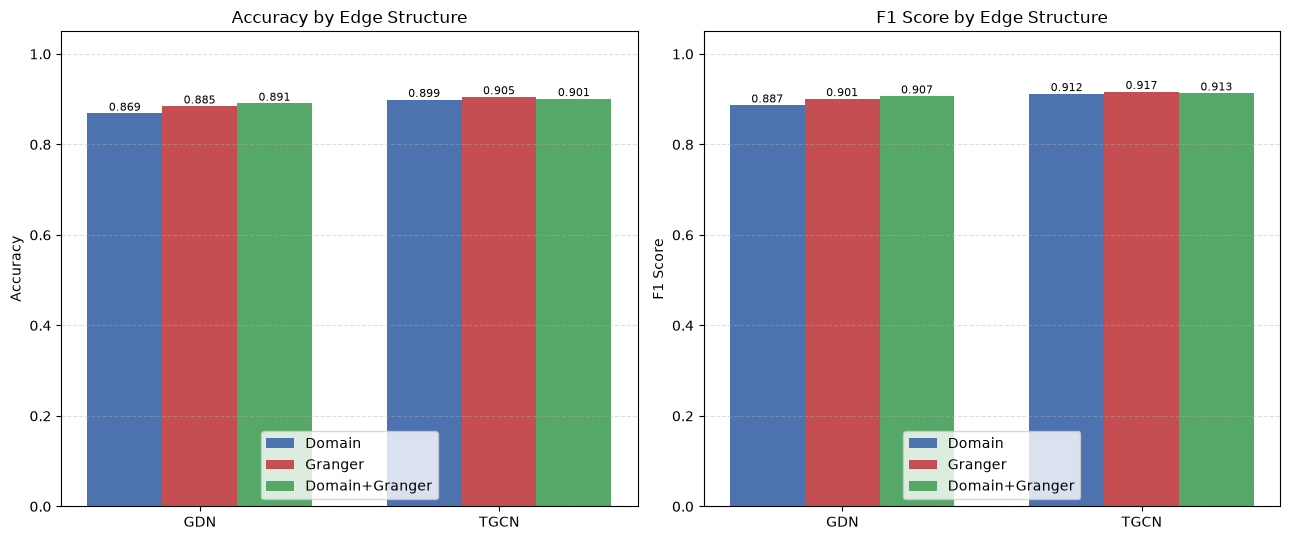

In [28]:

def clean_name(n):
    return (n.replace(" (Protocol B - official split)", "")
             .replace("Domain+Granger edges", "Domain+Granger")
             .replace("Domain edges", "Domain")
             .replace("Granger edges", "Granger"))


edge_ablation_pairs = [
    ("GDN (Domain edges)", "GDN (Granger edges)", "GDN (Domain+Granger edges)", "GDN"),
    ("TGCN (Domain edges)", "TGCN (Granger edges)", "TGCN (Domain+Granger edges)", "TGCN"),
]
edge_ablation_pairs = [t for t in edge_ablation_pairs if all(n in model_results for n in t[:3])]

variant_labels = ["Domain", "Granger", "Domain+Granger"]
variant_colors = ["#4C72B0", "#C44E52", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, metric in zip(axes, ["Accuracy", "F1 Score"]):
    x = np.arange(len(edge_ablation_pairs))
    width = 0.25
    for j, vlabel in enumerate(variant_labels):
        vals = [model_results[triplet[j]][metric] for triplet in edge_ablation_pairs]
        bars = ax.bar(x + (j - 1) * width, vals, width, label=vlabel, color=variant_colors[j])
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([t[3] for t in edge_ablation_pairs])
    ax.set_ylim(0, 1.05); ax.set_ylabel(metric)
    ax.set_title(f"{metric} by Edge Structure")
    ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_edge_structure_ablation.png", dpi=150, bbox_inches="tight")
plt.show()


### 8b. Protocol B model comparison — the primary result figure

Best GDN variant:  GDN (Domain+Granger edges)
Best TGCN variant: TGCN (Granger edges)


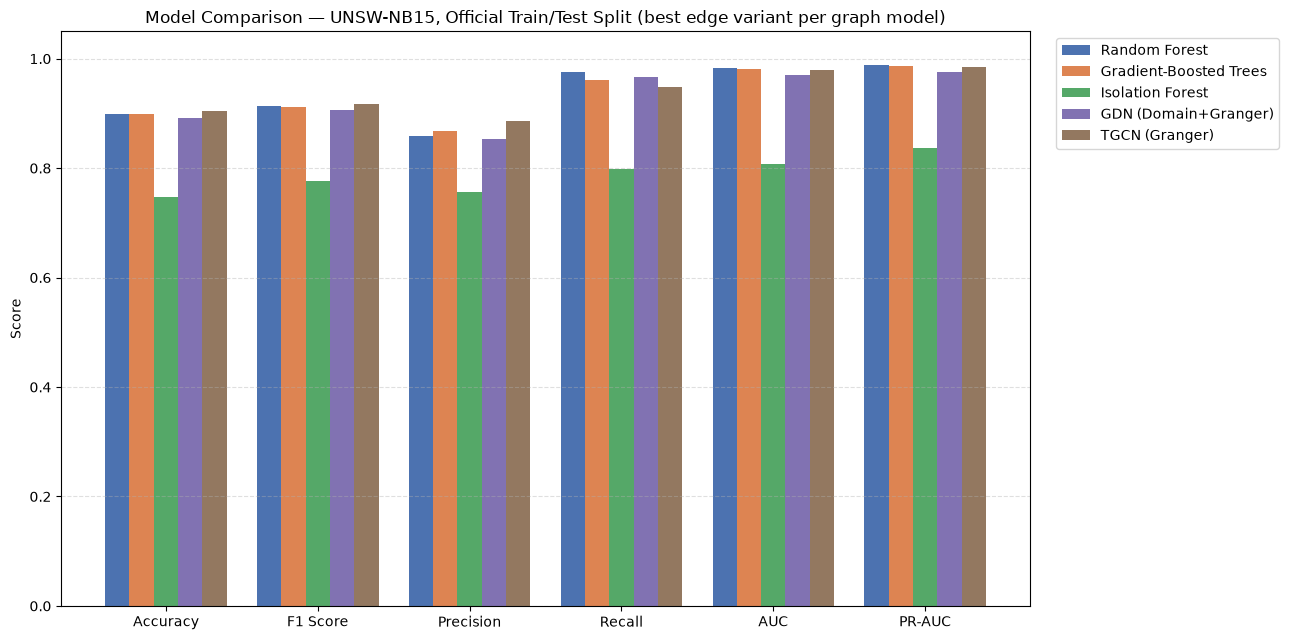

In [29]:

# Headline comparison uses the best edge-structure variant of each graph model
gdn_variants  = [n for n in model_results if n.startswith("GDN (") and model_results[n]["Protocol"] == "B: Official train/test split"]
tgcn_variants = [n for n in model_results if n.startswith("TGCN (") and model_results[n]["Protocol"] == "B: Official train/test split"]
best_gdn  = max(gdn_variants, key=lambda n: model_results[n]["F1 Score"]) if gdn_variants else None
best_tgcn = max(tgcn_variants, key=lambda n: model_results[n]["F1 Score"]) if tgcn_variants else None
print("Best GDN variant: ", best_gdn)
print("Best TGCN variant:", best_tgcn)

headline_models = [
    "Random Forest (Protocol B - official split)",
    "Gradient-Boosted Trees (Protocol B - official split)",
    "Isolation Forest (Protocol B - official split)",
    best_gdn, best_tgcn,
]
protocol_b_models = [n for n in headline_models if n and n in model_results]

metrics_to_plot = ["Accuracy", "F1 Score", "Precision", "Recall", "AUC", "PR-AUC"]
palette = ["#4C72B0", "#DD8452", "#55A868", "#8172B2", "#937860"]

x = np.arange(len(metrics_to_plot))
width = 0.8 / len(protocol_b_models)
fig, ax = plt.subplots(figsize=(13, 6.5))
for i, name in enumerate(protocol_b_models):
    vals = [model_results[name][m] for m in metrics_to_plot]
    ax.bar(x + (i - (len(protocol_b_models)-1)/2) * width, vals, width, label=clean_name(name), color=palette[i % len(palette)])
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title("Model Comparison \u2014 UNSW-NB15, Official Train/Test Split (best edge variant per graph model)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_protocol_b_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 8c. Leakage evidence - Protocol A vs Protocol B, same two models

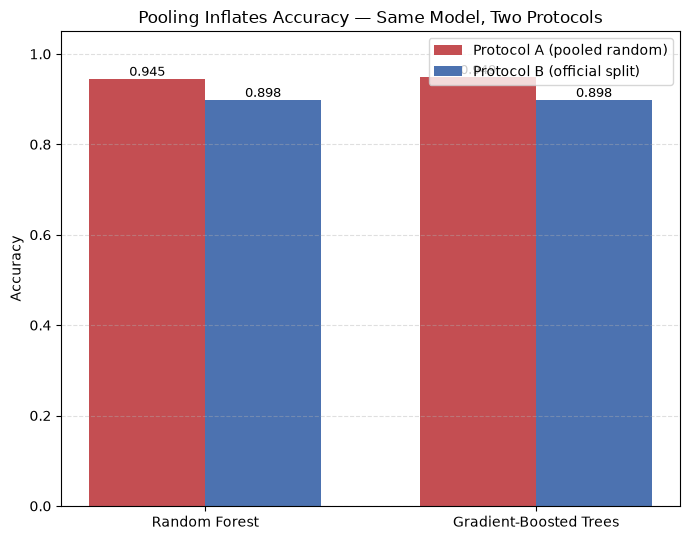

In [30]:

pairs = [
    ("RF (Protocol A - pooled random)", "Random Forest (Protocol B - official split)", "Random Forest"),
    ("Gradient-Boosted Trees (Protocol A - pooled random)", "Gradient-Boosted Trees (Protocol B - official split)", "Gradient-Boosted Trees"),
]
pairs = [(a, b, l) for a, b, l in pairs if a in model_results and b in model_results]
labels_p = [l for _, _, l in pairs]
acc_a = [model_results[a]["Accuracy"] for a, _, _ in pairs]
acc_b = [model_results[b]["Accuracy"] for _, b, _ in pairs]

x = np.arange(len(labels_p))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 5.5))
bars1 = ax.bar(x - width/2, acc_a, width, label="Protocol A (pooled random)", color="#C44E52")
bars2 = ax.bar(x + width/2, acc_b, width, label="Protocol B (official split)", color="#4C72B0")
for b in list(bars1) + list(bars2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels_p)
ax.set_ylim(0, 1.05); ax.set_ylabel("Accuracy")
ax.set_title("Pooling Inflates Accuracy \u2014 Same Model, Two Protocols")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_protocol_a_vs_b.png", dpi=150, bbox_inches="tight")
plt.show()
